<a href="https://colab.research.google.com/github/GabriellaJovanka/churn-customer--prediction/blob/main/ChurnPredict_Draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Ujian Akhir Semester — Bengkel Koding Data Science

---

**Topik:** Prediksi Customer Churn — Sales and Marketing Dataset  
**Jumlah Sampel:** 15.000 records | **Jumlah Kolom:** 30  

---

###Nama : Gabriella Jovanka Bustan
###NIM : A11.2023.14861

---

## 📦 0. Import Library

In [1]:
#Standard & Scientific
import pandas as pd
import numpy as np
import json, warnings, os
warnings.filterwarnings('ignore')

#Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#Model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# ─── Evaluasi & Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

#Deployment
import joblib

#Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
TEST_SIZE = 0.2

print("✅ Semua library berhasil diimport!")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   sklearn    : {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport!
   pandas     : 2.2.2
   numpy      : 2.0.2
   sklearn    : 1.6.1


---
## 📊 1. Exploratory Data Analysis (EDA)

### 1.1 Load Dataset

In [2]:
FILE_PATH = 'sales_marketing_customer_dataset.csv'

df = pd.read_csv(FILE_PATH)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Baris   : {df.shape[0]:,}")
print(f"   Kolom   : {df.shape[1]}")

✅ Dataset berhasil dimuat!
   Baris   : 4,723
   Kolom   : 30


### 1.2 Lima Baris Pertama, Info, & Statistik Deskriptif

In [3]:
#5 Baris Pertama
print("=" * 60)
print("5 BARIS PERTAMA DATASET")
print("=" * 60)
display(df.head())

5 BARIS PERTAMA DATASET


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
#Informasi Dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4723 entries, 0 to 4722
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 4723 non-null   int64  
 1   gender                      4483 non-null   object 
 2   age                         4370 non-null   float64
 3   country                     4723 non-null   object 
 4   city                        4723 non-null   object 
 5   signup_date                 4723 non-null   object 
 6   last_purchase_date          4723 non-null   object 
 7   acquisition_channel         4723 non-null   object 
 8   device_type                 4723 non-null   object 
 9   subscription_type           4723 non-null   object 
 10  is_premium_user             4723 non-null   int64  
 11  total_visits                4723 non-null   int64  
 12  avg_session_time            4723 non-null   float64
 13  pages_per_sessi

In [5]:
#Statistik Deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
display(df.describe().T.style.background_gradient(cmap='Blues'))

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
customer_id,4723.000000,12362.000000,1363.556991,10001.000000,11181.500000,12362.000000,13542.500000,14723.000000
age,4370.000000,35.335240,10.610500,-1.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,4723.000000,0.302562,0.459416,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,4723.000000,14.938598,3.866421,3.000000,12.000000,15.000000,17.000000,31.000000
avg_session_time,4723.000000,8.015953,2.922248,0.053215,6.063124,7.978772,9.997706,17.858533
pages_per_session,4723.000000,3.992246,1.472786,0.028358,2.992790,3.948604,4.988411,9.197071
email_open_rate,4723.000000,0.501565,0.291352,0.000000,0.240000,0.500000,0.760000,1.000000
email_click_rate,4723.000000,0.248149,0.144491,0.000000,0.120000,0.250000,0.370000,0.500000
total_spent,4388.000000,530.539489,413.513765,0.606682,309.120007,504.252881,711.183783,9897.033086
avg_order_value,4723.000000,60.447180,24.579598,0.191509,43.654641,60.613149,76.884829,149.111471


### 1.3 Analisis Missing Value

⚠️  Kolom dengan missing value: 5


,Missing Count,Missing (%)
coupon_code,1963,41.562566
age,353,7.474063
total_spent,335,7.092949
gender,240,5.081516
satisfaction_score,238,5.039170


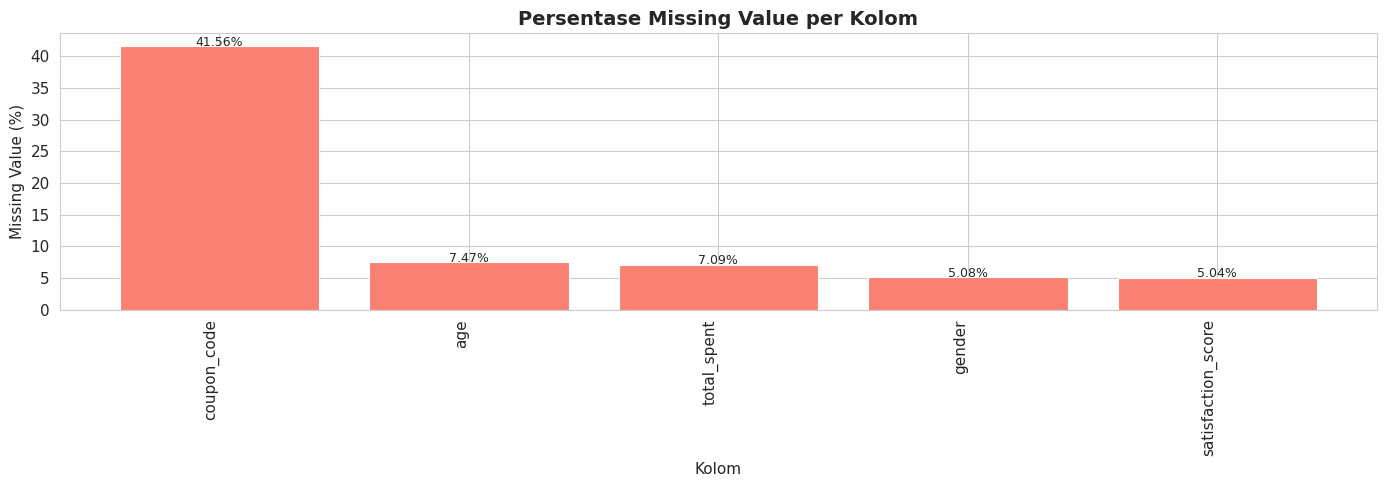

In [6]:
#Hitung Missing Value
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)':   missing_pct
}).sort_values('Missing (%)', ascending=False)

# Tampilkan tabel
has_missing = missing_df[missing_df['Missing Count'] > 0]
if has_missing.empty:
    print("✅ Tidak ada missing value pada dataset!")
else:
    print(f"⚠️  Kolom dengan missing value: {len(has_missing)}")
    display(has_missing.style.background_gradient(cmap='Reds', subset=['Missing (%)']))

#Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(14, 5))

if has_missing.empty:
    ax.text(0.5, 0.5, '✅ Tidak Ada Missing Value',
            ha='center', va='center', fontsize=16, color='green',
            transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
else:
    cols_mv = missing_pct[missing_pct > 0].sort_values(ascending=False)
    bars = ax.bar(cols_mv.index, cols_mv.values, color='salmon', edgecolor='white', linewidth=0.8)
    ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
    ax.set_xlabel('Kolom'); ax.set_ylabel('Missing Value (%)')
    ax.set_xticks(range(len(cols_mv))); ax.set_xticklabels(cols_mv.index, rotation=90, ha='right')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.4 Distribusi Variabel Target (Churn)

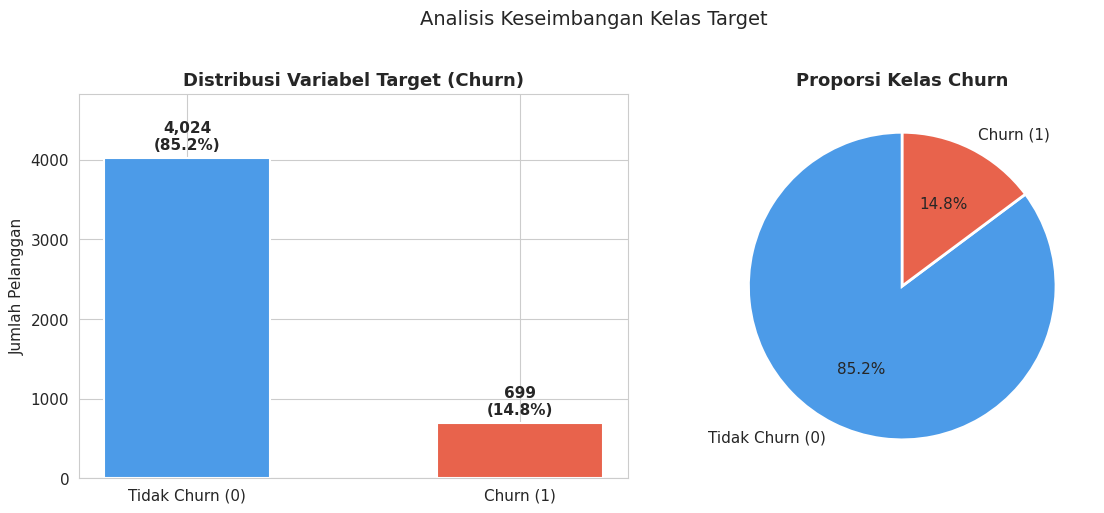


📌 Distribusi Kelas:
   Churn = 0 (Tidak Churn) : 4,024 (85.20%)
   Churn = 1 (Churn)       : 699 (14.80%)
   Rasio kelas             : 5.76:1
   ⚠️  Dataset mengalami class imbalance — pertimbangkan SMOTE/class_weight.


In [7]:
#Distribusi Churn
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4C9BE8', '#E8634C']
labels = ['Tidak Churn (0)', 'Churn (1)']
bars = axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Distribusi Variabel Target (Churn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Distribusi Kelas:")
print(f"   Churn = 0 (Tidak Churn) : {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"   Churn = 1 (Churn)       : {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")
ratio = churn_counts.max() / churn_counts.min()
print(f"   Rasio kelas             : {ratio:.2f}:1")
if ratio > 2:
    print("   ⚠️  Dataset mengalami class imbalance — pertimbangkan SMOTE/class_weight.")
else:
    print("   ✅ Dataset relatif seimbang.")

### 1.5 Heatmap Korelasi Fitur Numerik

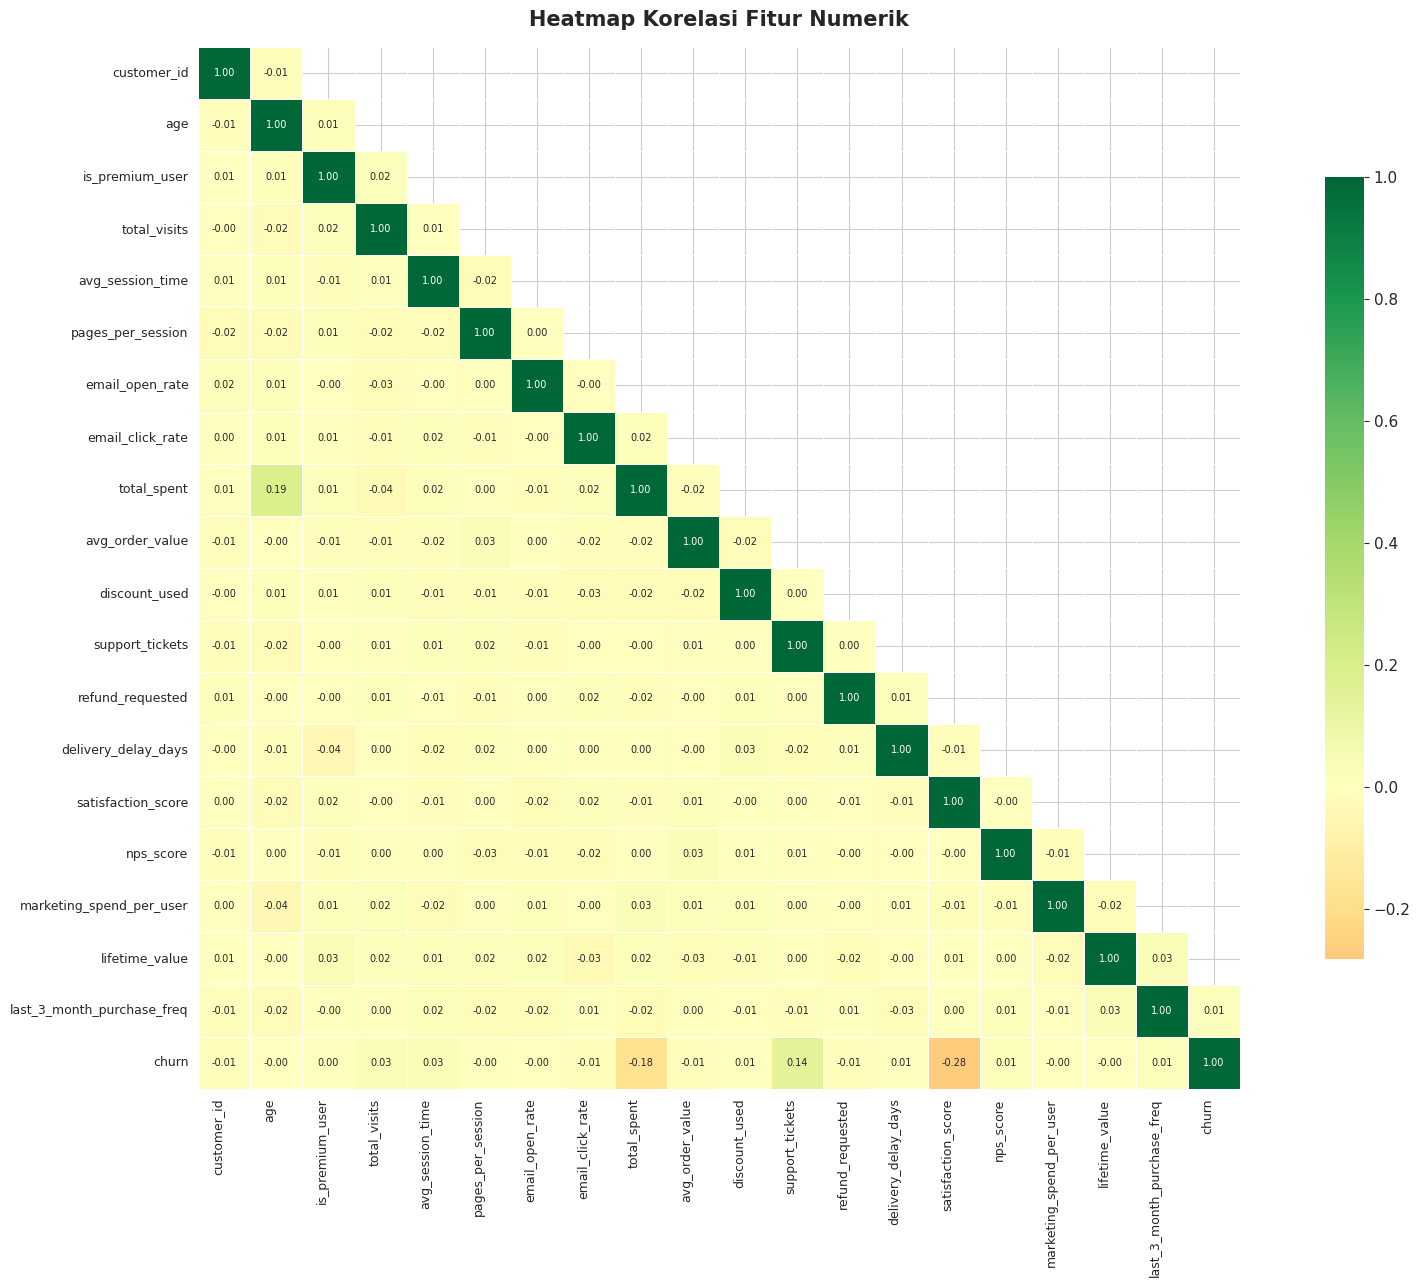


📌 Korelasi Teratas dengan Variabel Churn:


,|Korelasi| dengan Churn
satisfaction_score,0.281085
total_spent,0.176554
support_tickets,0.144748
avg_session_time,0.030988
total_visits,0.030679
avg_order_value,0.014618
email_click_rate,0.014306
nps_score,0.012951
refund_requested,0.012778
last_3_month_purchase_freq,0.012547


In [8]:
#Heatmap Korelasi
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(18, 13))
mask = np.tril(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr,
            mask=~mask,          # tampilkan segitiga bawah
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75},
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

#Top korelasi dengan churn
print("\n📌 Korelasi Teratas dengan Variabel Churn:")
churn_corr = corr['churn'].drop('churn').abs().sort_values(ascending=False)
display(churn_corr.head(10).rename('|Korelasi| dengan Churn')
         .to_frame().style.bar(color='steelblue'))

---
## 🤖 2. Direct Modeling



In [9]:
df = pd.read_csv('sales_marketing_customer_dataset.csv')

# 1. Simple Encoding untuk tipe Object dan Datetime
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        # Cek apakah kolom adalah datetime (berdasarkan nama kolom yang mengandung 'date')
        if 'date' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
            # Konversi datetime ke bentuk int64 (timestamp dalam detik)
            df[col] = df[col].astype('int64') // 10**9
        else:
            # Label encode untuk fitur kategorikal
            df[col] = le.fit_transform(df[col].astype(str))

In [10]:
# 2. Menetapkan Variabel Target (y) dan Prediktor (X)
if 'customer id' in df.columns:
    df = df.drop(columns=['customer id']) # Menghapus id unik karena bukan prediktor valid

X = df.drop(columns=['churn'])
y = df['churn']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 4. Inisialisasi Tiga Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

voting_clf = VotingClassifier(
    estimators=[('lr', log_reg), ('svm', svm), ('knn', knn)],
    voting='soft'
)

models = {
    'Conventional (Logistic Regression)': log_reg,
    'Bagging Ensemble (Random Forest)': rf,
    'Voting Classifier (LR, SVM, KNN)': voting_clf
}

In [12]:
# 5. Melatih Model dan Evaluasi

# Drop rows with missing values from training data
# Combine X_train and y_train to drop rows where either has NaN
train_data = pd.concat([X_train, y_train], axis=1)
train_data_cleaned = train_data.dropna()
X_train_processed = train_data_cleaned.drop(columns=['churn'])
y_train_processed = train_data_cleaned['churn']

# Drop rows with missing values from test data
# Combine X_test and y_test to drop rows where either has NaN
test_data = pd.concat([X_test, y_test], axis=1)
test_data_cleaned = test_data.dropna()
X_test_processed = test_data_cleaned.drop(columns=['churn'])
y_test_processed = test_data_cleaned['churn']

for name, model in models.items():
    print(f"\n--- {name} ---")
    # Training model secara langsung
    model.fit(X_train_processed, y_train_processed)

    # Prediksi
    y_pred = model.predict(X_test_processed)

    # Evaluasi Metrik
    print(f"Accuracy  : {accuracy_score(y_test_processed, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_processed, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test_processed, y_pred, zero_division=0):.4f}")
    print(f"F1-Score  : {f1_score(y_test_processed, y_pred, zero_division=0):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_processed, y_pred))
    print("\n")


--- Conventional (Logistic Regression) ---
Accuracy  : 0.8329
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
Confusion Matrix:
[[638   0]
 [128   0]]



--- Bagging Ensemble (Random Forest) ---
Accuracy  : 0.8290
Precision : 0.4706
Recall    : 0.1875
F1-Score  : 0.2682
Confusion Matrix:
[[611  27]
 [104  24]]



--- Voting Classifier (LR, SVM, KNN) ---
Accuracy  : 0.8329
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
Confusion Matrix:
[[638   0]
 [128   0]]




---
## 🧹 3. Modeling dengan Preprocessing

### 3.1 Penanganan Missing Value

In [13]:
# Salin dataset segar
df_prep = df.copy()
print(f"Shape awal: {df_prep.shape}")
print(f"Total missing sebelum: {df_prep.isnull().sum().sum()}")

# Kolom numerik → imputasi median
num_cols_prep = df_prep.select_dtypes(include=[np.number]).columns
for col in num_cols_prep:
    if df_prep[col].isnull().any():
        median_val = df_prep[col].median()
        df_prep[col].fillna(median_val, inplace=True)
        print(f"  [NUM] '{col}': missing diisi dengan median ({median_val:.2f})")

# Kolom kategorik → imputasi modus
cat_cols_prep = df_prep.select_dtypes(include=['object']).columns
for col in cat_cols_prep:
    if df_prep[col].isnull().any():
        mode_val = df_prep[col].mode()[0]
        df_prep[col].fillna(mode_val, inplace=True)
        print(f"  [CAT] '{col}': missing diisi dengan modus ('{mode_val}')")

print(f"\nTotal missing setelah: {df_prep.isnull().sum().sum()}")
print("✅ Penanganan missing value selesai.")

Shape awal: (4723, 30)
Total missing sebelum: 926
  [NUM] 'age': missing diisi dengan median (35.00)
  [NUM] 'total_spent': missing diisi dengan median (504.25)
  [NUM] 'satisfaction_score': missing diisi dengan median (4.00)

Total missing setelah: 0
✅ Penanganan missing value selesai.


### 3.2 Penanganan Duplikasi

In [14]:
# Duplikasi
dup_before = df_prep.duplicated().sum()
df_prep.drop_duplicates(inplace=True)
dup_after = df_prep.duplicated().sum()
print(f"Duplikat sebelum : {dup_before}")
print(f"Duplikat setelah : {dup_after}")
print(f"Shape setelah    : {df_prep.shape}")

Duplikat sebelum : 0
Duplikat setelah : 0
Shape setelah    : (4723, 30)


### 3.3 Penanganan Outlier (IQR Method)

In [15]:
# Outlier — IQR Capping (Winsorization)
# Menggunakan capping (bukan drop) agar data tidak berkurang terlalu banyak
outlier_cols = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                'email_open_rate', 'email_click_rate', 'total_spent',
                'avg_order_value', 'support_tickets', 'delivery_delay_days',
                'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
                'lifetime_value', 'last_3_month_purchase_freq']

outlier_summary = []
for col in outlier_cols:
    if col not in df_prep.columns:
        continue
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)
    outlier_summary.append({'Kolom': col, 'Lower Bound': round(lower, 2),
                             'Upper Bound': round(upper, 2), 'Outlier Capped': n_outlier})

df_outlier = pd.DataFrame(outlier_summary)
display(df_outlier.style.background_gradient(cmap='Oranges', subset=['Outlier Capped']))
print(f"\n✅ Outlier di-cap menggunakan batas IQR (Winsorization).")
print(f"   Shape dataset : {df_prep.shape}")

,Kolom,Lower Bound,Upper Bound,Outlier Capped
0,age,11.000000,59.000000,83
1,total_visits,4.500000,24.500000,75
2,avg_session_time,0.160000,15.900000,21
3,pages_per_session,-0.000000,7.980000,16
4,email_open_rate,-0.540000,1.540000,0
5,email_click_rate,-0.260000,0.740000,0
6,total_spent,-225.040000,1245.520000,43
7,avg_order_value,-6.190000,126.730000,17
8,support_tickets,-2.000000,6.000000,32
9,delivery_delay_days,-1.000000,7.000000,60



✅ Outlier di-cap menggunakan batas IQR (Winsorization).
   Shape dataset : (4723, 30)


### 3.4 Feature Engineering dari Kolom Datetime

In [16]:
# Ekstraksi Fitur dari Datetime
REF_DATE = pd.Timestamp('2024-01-01')

df_prep['signup_date']        = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

df_prep['tenure_days']              = (REF_DATE - df_prep['signup_date']).dt.days
df_prep['days_since_last_purchase'] = (REF_DATE - df_prep['last_purchase_date']).dt.days

# Isi NaN yang mungkin muncul dari konversi datetime
df_prep['tenure_days'].fillna(df_prep['tenure_days'].median(), inplace=True)
df_prep['days_since_last_purchase'].fillna(df_prep['days_since_last_purchase'].median(), inplace=True)

print("Fitur baru yang ditambahkan:")
print(f"  - tenure_days              : {df_prep['tenure_days'].describe().to_dict()}")
print(f"  - days_since_last_purchase : {df_prep['days_since_last_purchase'].describe().to_dict()}")

Fitur baru yang ditambahkan:
  - tenure_days              : {'count': 4723.0, 'mean': 19722.0, 'std': 0.0, 'min': 19722.0, '25%': 19722.0, '50%': 19722.0, '75%': 19722.0, 'max': 19722.0}
  - days_since_last_purchase : {'count': 4723.0, 'mean': 19722.0, 'std': 0.0, 'min': 19722.0, '25%': 19722.0, '50%': 19722.0, '75%': 19722.0, 'max': 19722.0}


### 3.5 Drop Fitur Tidak Relevan

In [17]:
# Drop Fitur Tidak Relevan
# customer_id    → hanya identifier, tidak informatif
# signup_date    → sudah dikonversi ke tenure_days
# last_purchase_date → sudah dikonversi ke days_since_last_purchase
# coupon_code    → kardinalitas tinggi, dominan unik
# city / country → kardinalitas sangat tinggi, sulit dimanfaatkan tanpa target encoding

drop_prep = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city', 'country']
df_prep.drop(columns=[c for c in drop_prep if c in df_prep.columns], inplace=True)

print(f"Kolom dihapus   : {drop_prep}")
print(f"Shape setelah   : {df_prep.shape}")
print(f"\nKolom tersisa  : {df_prep.columns.tolist()}")

Kolom dihapus   : ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city', 'country']
Shape setelah   : (4723, 26)

Kolom tersisa  : ['gender', 'age', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn', 'tenure_days', 'days_since_last_purchase']


### 3.6 Encoding Fitur Kategorikal

In [18]:
# Label Encoding untuk Fitur Kategorikal
cat_enc_cols = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal yang akan di-encode: {cat_enc_cols}\n")

le_encoders = {}
for col in cat_enc_cols:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    le_encoders[col] = le
    print(f"  ✅ '{col}' — kelas: {list(le.classes_)[:5]}{'...' if len(le.classes_)>5 else ''}")

print(f"\nShape setelah encoding: {df_prep.shape}")
display(df_prep.head(3))

Kolom kategorikal yang akan di-encode: []


Shape setelah encoding: (4723, 26)


,gender,age,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,...,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,tenure_days,days_since_last_purchase
0,1,52.0,0,2,0,1,7.0,13.903745,5.415164,0.67,...,3,4,3.0,10,27.56,915.310827,14,0,19722,19722
1,3,35.0,3,0,1,0,19.0,5.112528,5.352441,0.70,...,3,0,3.0,7,15.15,2079.960938,11,0,19722,19722
2,0,27.0,0,1,0,1,18.0,9.742749,3.594719,0.47,...,2,4,5.0,6,13.51,1379.150885,9,0,19722,19722


### 3.7 Set Fitur & Target, Train–Test Split

In [19]:
# X dan y
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

print(f"Shape X: {X_prep.shape}  |  Shape y: {y_prep.shape}")
print(f"Distribusi y: {dict(y_prep.value_counts())}")

# Train–Test Split (proporsi sama: 80:20)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_prep, y_prep,
    test_size=TEST_SIZE, random_state=SEED, stratify=y_prep
)
print(f"\nData Latih : {X_tr_p.shape[0]:,} samples")
print(f"Data Uji   : {X_te_p.shape[0]:,} samples")

Shape X: (4723, 25)  |  Shape y: (4723,)
Distribusi y: {0: np.int64(4024), 1: np.int64(699)}

Data Latih : 3,778 samples
Data Uji   : 945 samples


### 3.8 Scaling (setelah Data Splitting)

In [20]:
# StandardScaler — fit pada train, transform keduanya
scaler = StandardScaler()
X_tr_p_sc = scaler.fit_transform(X_tr_p)   # fit HANYA pada train
X_te_p_sc  = scaler.transform(X_te_p)      # transform test tanpa re-fit

print("✅ StandardScaler diterapkan.")
print(f"   Mean (train) rata-rata : {scaler.mean_.mean():.4f}")
print(f"   Std  (train) rata-rata : {scaler.scale_.mean():.4f}")

✅ StandardScaler diterapkan.
   Mean (train) rata-rata : 1654.2786
   Std  (train) rata-rata : 39.8967


### 3.9 Training & Evaluasi (Preprocessing)

In [21]:
if 'results_all' not in globals():
    results_all = []

def evaluate_model(model, X_test, y_test, model_name, scenario):
    global results_all

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\n")

    results_all.append({
        'Scenario': scenario,
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Model 1: Logistic Regression + Preprocessing
print("⏳ Training Logistic Regression (Preprocessing)...")
lr_p = LogisticRegression(max_iter=1000, random_state=SEED)
lr_p.fit(X_tr_p_sc, y_tr_p)
evaluate_model(lr_p, X_te_p_sc, y_te_p, "Logistic Regression", "Preprocessing")

⏳ Training Logistic Regression (Preprocessing)...
Accuracy  : 0.8444
Precision : 0.4255
Recall    : 0.1429
F1-Score  : 0.2139
Confusion Matrix:
[[778  27]
 [120  20]]




In [22]:
# Model 2: Random Forest + Preprocessing
print("⏳ Training Random Forest (Preprocessing)...")
rf_p = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_p.fit(X_tr_p_sc, y_tr_p)
evaluate_model(rf_p, X_te_p_sc, y_te_p, "Random Forest", "Preprocessing")

⏳ Training Random Forest (Preprocessing)...
Accuracy  : 0.8349
Precision : 0.4024
Recall    : 0.2357
F1-Score  : 0.2973
Confusion Matrix:
[[756  49]
 [107  33]]




In [23]:
# Model 3: Voting Classifier + Preprocessing
print("⏳ Training Voting Classifier (Preprocessing)...")
estimators_p = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=SEED)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=SEED)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
vc_p = VotingClassifier(estimators=estimators_p, voting='soft', n_jobs=-1)
vc_p.fit(X_tr_p_sc, y_tr_p)
evaluate_model(vc_p, X_te_p_sc, y_te_p, "Voting Classifier", "Preprocessing")

⏳ Training Voting Classifier (Preprocessing)...
Accuracy  : 0.8508
Precision : 0.4737
Recall    : 0.0643
F1-Score  : 0.1132
Confusion Matrix:
[[795  10]
 [131   9]]




In [24]:
# Ringkasan Preprocessing Modeling
df_prep_results = pd.DataFrame([r for r in results_all if r['Scenario'] == 'Preprocessing'])
print("\n" + "="*55)
print("  RINGKASAN PREPROCESSING MODELING")
print("="*55)
display(df_prep_results.set_index('Model').drop(columns='Scenario')
         .style.highlight_max(color='#c6efce', axis=0)
         .format('{:.4f}'))


  RINGKASAN PREPROCESSING MODELING


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8444,0.4255,0.1429,0.2139
Random Forest,0.8349,0.4024,0.2357,0.2973
Voting Classifier,0.8508,0.4737,0.0643,0.1132
